In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, ConfusionMatrixDisplay

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [3]:
# For when exploring imb techniques
from imblearn.pipeline import Pipeline as imb_Pipeline
from imblearn.over_sampling import SMOTE

In [6]:
from pathlib import Path
import sys

this_file = Path.cwd()
ROOT = Path(this_file).resolve().parent
print(ROOT)
sys.path.append(str(ROOT))

from app.config import DATASET_FILE

C:\Users\Carl Sebastian\(new) VS_projects\aegis-vanguard-network-attack-detection-system


In [7]:
new_data = pd.read_csv(DATASET_FILE, encoding='latin-1')

In [8]:
attack_data = new_data[new_data['Label'] != "BENIGN"].copy()

X = attack_data.drop(columns = "Label")
Y = attack_data["Label"]

In [9]:
X = pd.DataFrame(np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0),
                 columns=X.columns,
                 index=X.index,
                 )

In [10]:
# Detect inf and nan vals
print(np.isinf(X.values).any())
print(np.isnan(X.values).any()) 

False
False


In [ ]:
X.shape

In [ ]:
Y.shape

In [11]:
def map_layer2_labels(Y):
    Y = Y.copy()
    Y = Y.replace({
        "Web Attack - Sql Injection": "Web Attack",
        "Web Attack - Brute Force": "Web Attack",
        "Web Attack - XSS": "Web Attack"
    })

    return Y

Y = map_layer2_labels(Y)

In [12]:
Y.unique()

<StringArray>
[        'PortScan',       'Web Attack',      'FTP-Patator',
      'SSH-Patator',             'DDoS',              'Bot',
     'Infiltration',    'DoS slowloris', 'DoS Slowhttptest',
         'DoS Hulk',    'DoS GoldenEye',       'Heartbleed']
Length: 12, dtype: str

In [ ]:
Y.value_counts()

In [13]:
# Train-Test-Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.25, stratify = Y_train, random_state=42)

In [14]:
# Preprocessor pipeline (utilized a columntransformer approach because of utilization of imblearn pipeline)
prob_cols = X.columns.tolist()
preprocessor_transformer = ColumnTransformer(
    transformers=[
        ("numeric",  SimpleImputer(missing_values=np.nan, strategy='constant', fill_value=0), prob_cols)
    ],
    remainder="passthrough"
)

In [15]:
label_encoder = LabelEncoder()
Y_train = label_encoder.fit_transform(Y_train)
Y_val   = label_encoder.transform(Y_val)
Y_test  = label_encoder.transform(Y_test)

id_to_label = dict(enumerate(label_encoder.classes_))

print(id_to_label)

{0: 'Bot', 1: 'DDoS', 2: 'DoS GoldenEye', 3: 'DoS Hulk', 4: 'DoS Slowhttptest', 5: 'DoS slowloris', 6: 'FTP-Patator', 7: 'Heartbleed', 8: 'Infiltration', 9: 'PortScan', 10: 'SSH-Patator', 11: 'Web Attack'}


In [ ]:
def model_evaluation(pipeline, X_val, Y_val, id_to_label):
    Y_pred = pipeline.predict(X_val)
    Y_pred_proba = pipeline.predict_proba(X_val)

    label_keys = list(id_to_label.keys())
    label_values = list(id_to_label.values())
    enc_names = [f"{i}: {id_to_label[i]}" for i in label_keys]

    print(classification_report(
        Y_val,
        Y_pred,
        target_names=enc_names
    ))

    cm = confusion_matrix(Y_val, Y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_values)

    plt.figure(figsize=(14, 12))
    disp.plot(xticks_rotation=90, cmap="Blues")
    plt.title("Confusion Matrix (Multi-Class IDS)")
    plt.show()

    print("Micro ROC-AUC:",
          roc_auc_score(Y_val, Y_pred_proba,
                        multi_class="ovr",
                        average="micro"))

    print("Macro ROC-AUC:",
          roc_auc_score(Y_val, Y_pred_proba,
                        multi_class="ovr",
                        average="macro"))

    recalls = recall_score(Y_val, Y_pred, average=None, labels=label_keys)
    recall_df = pd.DataFrame({
        "label": label_values,
        "recall": recalls
    }).sort_values("recall")
    print("\n", recall_df)

In [ ]:
base_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_transformer),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

base_pipeline.fit(X_train, Y_train)
model_evaluation(base_pipeline, X_val, Y_val, id_to_label)

### Utilization of SMOTE (Synthetic Minority Oversampling Technique)

Seeing the large imbalance in the dataset and the model's inability to generalize, particulary samples for Infiltration, I've decided to use SMOTE. This is so the approach will not just duplicate data but interpolate the other minority samples.

In [ ]:
total_pipeline1 = imb_Pipeline(
    steps=[
        ("preprocessing", preprocessor_transformer),
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(class_weight=None, random_state=42, n_jobs=-1))
    ]
)

total_pipeline1.fit(X_train, Y_train)
model_evaluation(total_pipeline1, X_val, Y_val, id_to_label)

### Cost-Sensitive Learning via Class Weighting

Seeing that SMOTE has failed to increase the recall for Infiltration, the next approach is to use this approach. Cost Sensitive Learning basically increases the weight of the samples for Infiltration so the model will prioritie detecting this attack type

In [ ]:
class_weight_custom = {
    0: 1,
    1: 1,
    2: 1,
    3: 1,
    4: 1,
    5: 1,
    6: 1,
    7: 1,
    8: 3,   # Infiltration boosted
    9: 1,
    10: 1,
    11: 1
}

In [ ]:
total_pipeline2 = Pipeline(
    steps=[
        ("preprocessing", preprocessor_transformer),
        ("model", RandomForestClassifier(
            class_weight=class_weight_custom,
            n_jobs=-1,
            random_state=42
        ))
    ]
)

total_pipeline2.fit(X_train, Y_train)
model_evaluation(total_pipeline2, X_val, Y_val, id_to_label)

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier

total_pipeline3 = Pipeline(
    steps=[
        ("preprocessing", preprocessor_transformer),
        ("model", BalancedRandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

total_pipeline3.fit(X_train, Y_train)
model_evaluation(total_pipeline3, X_val, Y_val, id_to_label)

### XGboost

Given that the above techniques have not improved the performance on Infiltration, boosting method is the next logical step.

Unlike Random Forest, which builds trees independently, boosting methods train trees **sequentially**, where each new tree focuses on correcting errors made by previous trees. This allows the model to place greater emphasis on difficult-to-classify samples.

For this multiclass classification task, the objective function `multi:softprob` is used, unlike the bianry in first layer. This configuration outputs a probability distribution over all attack classes, allowing both prediction and probability-based evaluation metrics such as ROC-AUC.

In [ ]:
# # Cost sensitive learning approach to account for Infiltration

# class_weight_custom = {
#     0: 1,
#     1: 1,
#     2: 1,
#     3: 1,
#     4: 1,
#     5: 1,
#     6: 1,
#     7: 1,
#     8: 3,   # Infiltration boosted
#     9: 1,
#     10: 1,
#     11: 1
# }

# sample_weights = np.array([class_weight_custom[y] for y in Y_train])

                     precision    recall  f1-score   support

             0: Bot       1.00      1.00      1.00       393
            1: DDoS       1.00      1.00      1.00     25605
   2: DoS GoldenEye       1.00      1.00      1.00      2059
        3: DoS Hulk       1.00      1.00      1.00     46214
4: DoS Slowhttptest       0.99      1.00      1.00      1100
   5: DoS slowloris       1.00      0.99      0.99      1159
     6: FTP-Patator       1.00      1.00      1.00      1588
      7: Heartbleed       1.00      1.00      1.00         2
    8: Infiltration       1.00      0.71      0.83         7
        9: PortScan       1.00      1.00      1.00     31786
    10: SSH-Patator       1.00      1.00      1.00      1180
     11: Web Attack       0.99      0.99      0.99       436

           accuracy                           1.00    111529
          macro avg       1.00      0.97      0.98    111529
       weighted avg       1.00      1.00      1.00    111529



<Figure size 1400x1200 with 0 Axes>

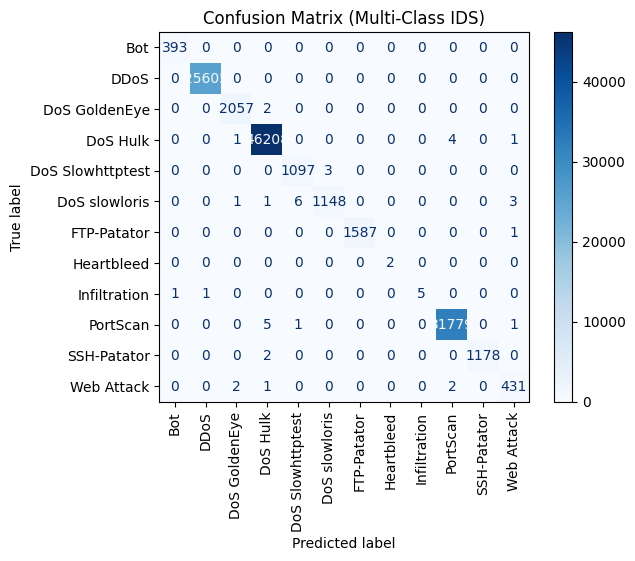

AxisError: axis 1 is out of bounds for array of dimension 1

In [17]:
total_pipeline4 = Pipeline(
    steps=[
        ("preprocessing", preprocessor_transformer),
        ("xgb_model", xgb.XGBClassifier(
            n_estimators=500, 
            learning_rate=0.1, # Step size shrinkage. Lower = slow learning, but stable. 0.01-0.1 is standard
            max_depth=6, # Conventional sweetspot per sources
            subsample=0.8, # Basically use 80 percent of the rows per tree
            colsample_bytree=0.8, # Basically use 80 percent of the features per tree
            gamma=0.1, 
            min_child_weight=3,
            objective="multi:softprob", # because we are doing multiclass classification
            num_class=len(np.unique(Y_train)), # In conjuction with obj..Exclusive to multiclass
            eval_metric="mlogloss", # Evaluation metric
            tree_method="hist", # To use CPU acceleration
            random_state=42,
            n_jobs=-1
        ))
    ]
)

total_pipeline4.fit(X_train, Y_train)
model_evaluation(total_pipeline4, X_val, Y_val, id_to_label)


In [ ]:
import joblib

final_model = total_pipeline1
joblib.dump(final_model, "layer2_rf_smote_pipeline.pkl")